#  DQN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://en.wikipedia.org/wiki/Q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
* https://github.com/pylSER/Deep-Reinforcement-learning-Mountain-Car/tree/master
* https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/

## Задачи для совместного разбора

1\. Обсудите основные отличия DQN от классических вариантов Q-learning.

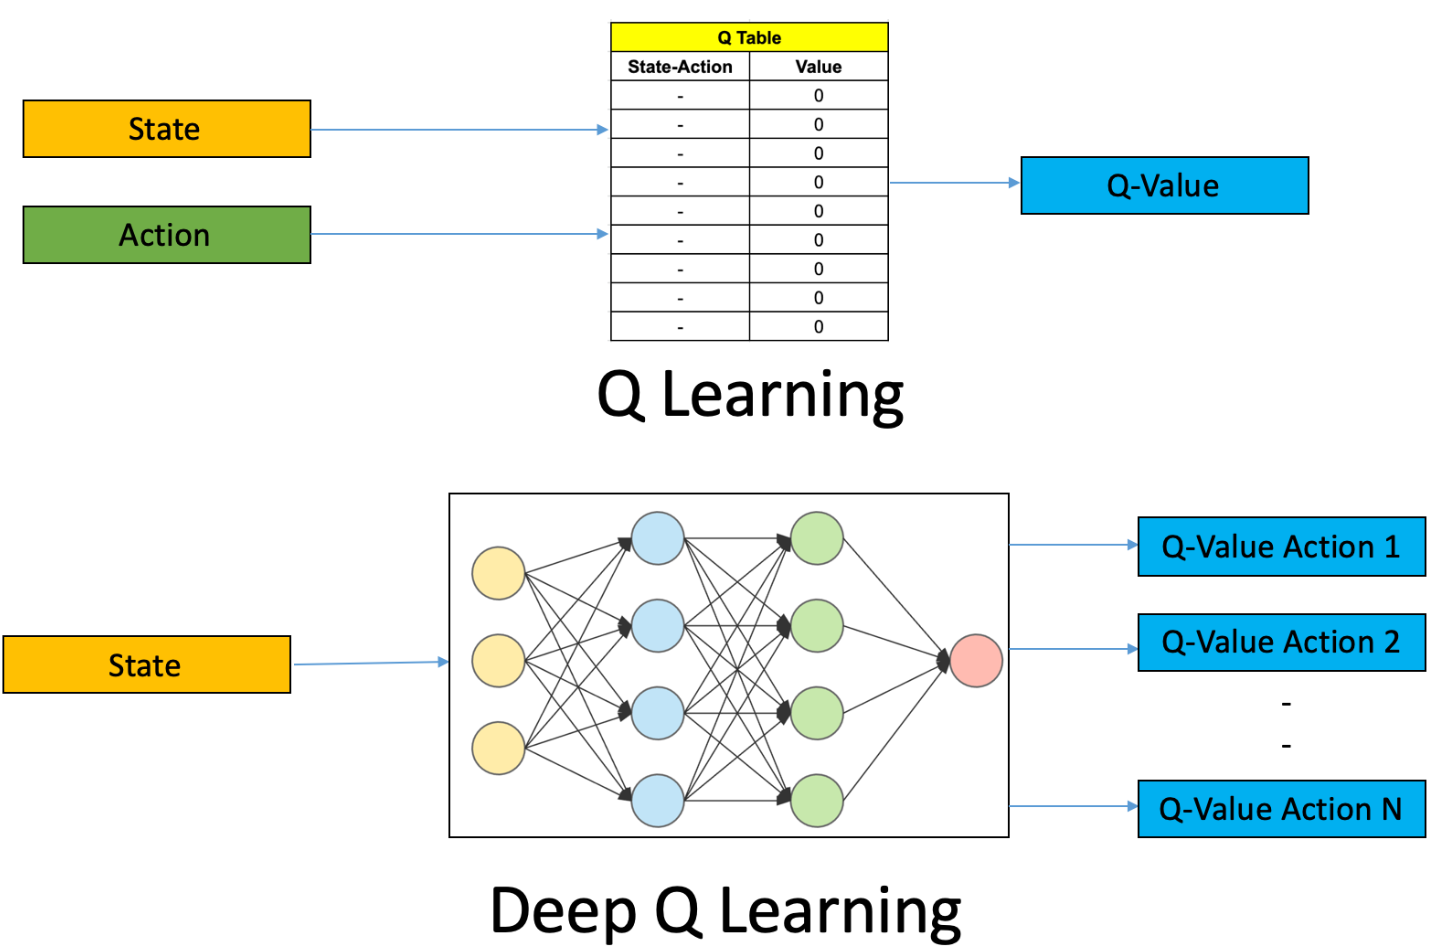

<img src="https://valohai.com/blog/reinforcement-learning-tutorial-part-1-q-learning/image4.png" width="500">
<img src="https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/4.png" width="500">


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите класс `ReplayMemory` для хранения переходов между состояниями.

- [ ] Проверено на семинаре

In [ ]:
from collections import namedtuple, deque
import random
import numpy as np

Transition = namedtuple(
    'Transition',
    ('state', 'action', 'next_state', 'reward', 'done')
)

class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        if len(self.memory) >= self.capacity:
            self.memory.popleft()
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)



In [ ]:
memory = ReplayMemory(capacity=5)

print(f"Initial memory size: {len(memory)}")
print(f"Memory capacity: {memory.capacity}\n")

print("Adding transitions...")
for i in range(7):
    state = np.array([i, i*2])
    action = i % 2
    next_state = np.array([i+1, (i+1)*2])
    reward = float(i * 0.1)
    done = (i == 6)

    memory.push(state, action, next_state, reward, done)
    print(f"Added transition {i}: state={state}, action={action}, reward={reward:.1f}, done={done}")
    print(f"  Memory size: {len(memory)}")

print(f"\nFinal memory size: {len(memory)} (oldest entries removed)")
print(f"\nMemory contents:")
for idx, transition in enumerate(memory.memory):
    print(f"  [{idx}] {transition}")


Initial memory size: 0
Memory capacity: 5

Adding transitions...
Added transition 0: state=[0 0], action=0, reward=0.0, done=False
  Memory size: 1
Added transition 1: state=[1 2], action=1, reward=0.1, done=False
  Memory size: 2
Added transition 2: state=[2 4], action=0, reward=0.2, done=False
  Memory size: 3
Added transition 3: state=[3 6], action=1, reward=0.3, done=False
  Memory size: 4
Added transition 4: state=[4 8], action=0, reward=0.4, done=False
  Memory size: 5
Added transition 5: state=[ 5 10], action=1, reward=0.5, done=False
  Memory size: 5
Added transition 6: state=[ 6 12], action=0, reward=0.6, done=True
  Memory size: 5

Final memory size: 5 (oldest entries removed)

Memory contents:
  [0] Transition(state=array([2, 4]), action=0, next_state=array([3, 6]), reward=0.2, done=False)
  [1] Transition(state=array([3, 6]), action=1, next_state=array([4, 8]), reward=0.30000000000000004, done=False)
  [2] Transition(state=array([4, 8]), action=0, next_state=array([ 5, 10])

<p class="task" id="2"></p>

2\. Допишите класс `DQN` для моделирования Q-функции.

- [ ] Проверено на семинаре

In [ ]:
import torch.nn as nn

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = nn.functional.relu(self.layer1(x))
        x = nn.functional.relu(self.layer2(x))
        return self.layer3(x)


<p class="task" id="3"></p>

3\. Допишите классы `PolicyConfig` для настроек политики агента и `Policy` для реализации политики.

- [ ] Проверено на семинаре

In [ ]:
import torch as th
import torch.nn as nn
from dataclasses import dataclass
import random

@dataclass
class PolicyConfig:
    n_observations: int
    n_actions: int
    device: th.device
    epsilon: float = 1.0
    epsilon_min: float = 0.05
    epsilon_decay: float = 0.995

In [ ]:
class Policy:
    def __init__(self, policy_cfg: PolicyConfig):
        self.cfg = policy_cfg
        self.policy_network = DQN(policy_cfg.n_observations, policy_cfg.n_actions).to(policy_cfg.device)
        self.target_network = DQN(policy_cfg.n_observations, policy_cfg.n_actions).to(policy_cfg.device)
        self.sync_models()

    def sync_models(self):
        self.target_network.load_state_dict(self.policy_network.state_dict())

    def get_best_action(self, state: th.Tensor) -> int:
        if random.random() < self.cfg.epsilon:
            return random.randrange(self.cfg.n_actions)
        else:
            with th.no_grad():
                return self.policy_network(state).argmax().item()

    def save(self):
        th.save(self.policy_network.state_dict(), 'policy_network.pth')
        th.save(self.target_network.state_dict(), 'target_network.pth')

    def load(self):
        self.policy_network.load_state_dict(th.load('policy_network.pth'))
        self.target_network.load_state_dict(th.load('target_network.pth'))

<p class="task" id="4"></p>

4\. Напишите функцию `plot_metrics`, которая будет использоваться для визуализации процесса обучения: суммарной награды за каждый эпизод и максимальное значение x-координаты машины за эпизод. Для реализации можете воспользоваться `wandb` или любым другим удобным инструментом.

- [ ] Проверено на семинаре

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(episode_rewards, episode_max_positions):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(episode_rewards)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title('Episode Rewards')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(episode_max_positions)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Max Position')
    axes[1].set_title('Episode Max Position')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


<p class="task" id="5"></p>

5\. Допишите классы `TrainConfig` для настроек обучения и `Trainer` для реализации процесса обучения.

- [ ] Проверено на семинаре

In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from dataclasses import dataclass

@dataclass
class TrainConfig:
    discount: float = 0.99
    lr: float = 0.001
    n_episodes: int = 1000
    batch_size: int = 128
    memory_capacity: int = 10000
    sync_every: int = 10

In [ ]:
class Trainer:
    def __init__(self, env: gym.Env, train_config: TrainConfig, policy: Policy):
        self.env = env
        self.cfg = train_config
        self.policy = policy
        self.memory = ReplayMemory(train_config.memory_capacity)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(policy.policy_network.parameters(), lr=train_config.lr)

    def train(self):
        episode_rewards = []
        episode_max_positions = []
        best_position = -float('inf')

        for episode in range(self.cfg.n_episodes):
            state, info = self.env.reset()
            state = th.tensor(state, dtype=th.float32, device=self.policy.cfg.device).unsqueeze(0)

            episode_reward, max_position = self.run_episode(state)

            episode_rewards.append(episode_reward)
            episode_max_positions.append(max_position)

            if (episode + 1) % 50 == 0:
                print(f"Episode {episode+1}: Reward={episode_reward:.2f}, Max Position={max_position:.4f}, ε={self.policy.cfg.epsilon:.4f}")

            if max_position > best_position:
                best_position = max_position
                self.policy.save()

        plot_metrics(episode_rewards, episode_max_positions)
        return episode_rewards, episode_max_positions

    def run_episode(self, start_state: th.Tensor):
        state = start_state
        done = False
        episode_reward = 0
        max_position = -float('inf')

        while not done:
            action = self.policy.get_best_action(state)
            observation, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated

            max_position = max(max_position, observation[0])
            episode_reward += reward

            next_state = th.tensor(observation, dtype=th.float32, device=self.policy.cfg.device).unsqueeze(0)

            self.memory.push(state, action, next_state, reward, done)

            state = next_state

            if len(self.memory) >= self.cfg.batch_size:
                self.generate_batch_and_fit()

        self.policy.cfg.epsilon = max(self.policy.cfg.epsilon_min,
                                       self.policy.cfg.epsilon * self.policy.cfg.epsilon_decay)

        return episode_reward, max_position

    def generate_batch_and_fit(self):
        transitions = self.memory.sample(self.cfg.batch_size)

        states = th.cat([t.state for t in transitions])
        next_states = th.cat([t.next_state for t in transitions])

        targets = self.policy.policy_network(states)
        next_state_targets = self.policy.target_network(next_states)

        for i, t in enumerate(transitions):
            if t.done:
                targets[i][t.action] = t.reward
            else:
                targets[i][t.action] = t.reward + self.cfg.discount * next_state_targets[i].max()

        self.fit_policy_network(states, targets)

    def fit_policy_network(self, X, y):
        self.optimizer.zero_grad()
        predictions = self.policy.policy_network(X)
        loss = self.criterion(predictions, y)
        loss.backward()
        self.optimizer.step()


<p class="task" id="6"></p>

6\. Настройте модель для управления машиной в окружении `MountainCar-v0`. Для преобразования векторов состояний в тензоры используйте обертку `TransformObservation`. Выведите на экран график с информацией о процессе обучения. При необходимости вставьте скриншоты этих графиков.

- [ ] Проверено на семинаре

In [ ]:
import torch as th
import gymnasium as gym

device = th.device("cuda" if th.cuda.is_available() else "cpu")

env = gym.make('MountainCar-v0')

n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

print(f"Device: {device}")
print(f"Observations: {n_observations}")
print(f"Actions: {n_actions}")


Device: cpu
Observations: 2
Actions: 3


In [ ]:
policy_cfg = PolicyConfig(
    n_observations=n_observations,
    n_actions=n_actions,
    device=device,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

train_cfg = TrainConfig(
    discount=0.99,
    lr=0.001,
    n_episodes=500,
    batch_size=128,
    memory_capacity=10000,
    sync_every=10
)

policy = Policy(policy_cfg)
trainer = Trainer(env, train_cfg, policy)


Episode 50: Reward=-200.00, Max Position=-0.2767, ε=0.7783
Episode 100: Reward=-200.00, Max Position=-0.3815, ε=0.6058
Episode 150: Reward=-200.00, Max Position=-0.3915, ε=0.4715
Episode 200: Reward=-200.00, Max Position=-0.4509, ε=0.3670
Episode 250: Reward=-200.00, Max Position=-0.4181, ε=0.2856
Episode 300: Reward=-200.00, Max Position=-0.4585, ε=0.2223
Episode 350: Reward=-200.00, Max Position=-0.3873, ε=0.1730
Episode 400: Reward=-200.00, Max Position=-0.3997, ε=0.1347
Episode 450: Reward=-200.00, Max Position=-0.3391, ε=0.1048
Episode 500: Reward=-200.00, Max Position=-0.2852, ε=0.0816


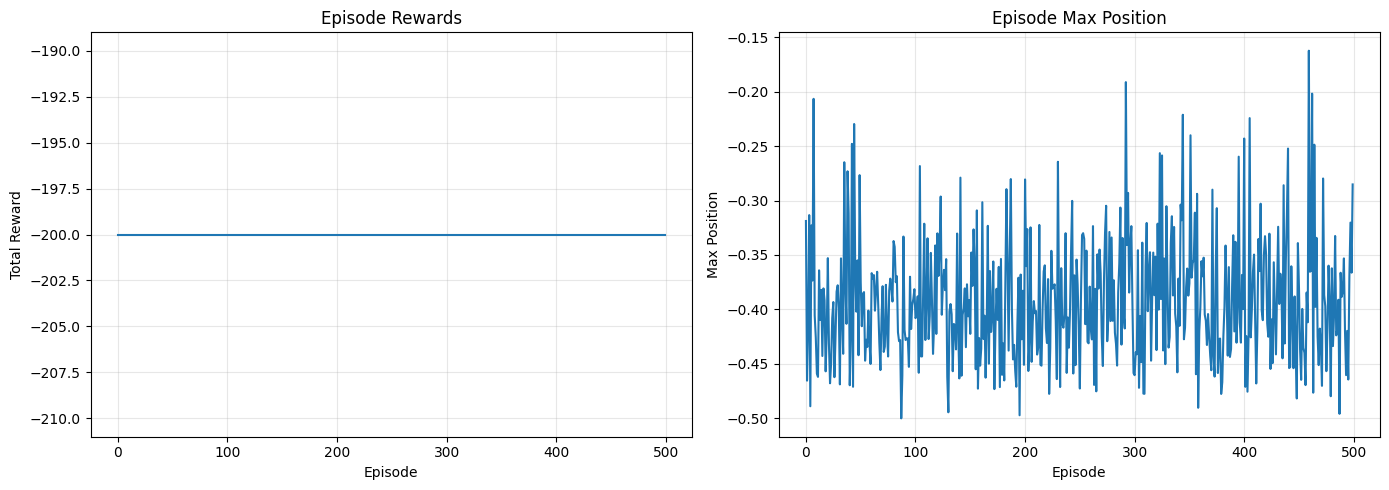

In [ ]:
episode_rewards, episode_max_positions = trainer.train()


In [ ]:
def run_episode(self, start_state: th.Tensor):
    state = start_state
    done = False
    episode_reward = 0
    max_position = -float('inf')
    steps = 0

    while not done:
        action = self.policy.get_best_action(state)
        observation, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated

        max_position = max(max_position, observation[0])
        episode_reward += reward

        next_state = th.tensor(observation, dtype=th.float32, device=self.policy.cfg.device).unsqueeze(0)

        self.memory.push(state, action, next_state, reward, done)

        state = next_state
        steps += 1

        if len(self.memory) >= self.cfg.batch_size:
            self.generate_batch_and_fit()

        if steps % self.cfg.sync_every == 0:
            self.policy.sync_models()

    self.policy.cfg.epsilon = max(self.policy.cfg.epsilon_min,
                                   self.policy.cfg.epsilon * self.policy.cfg.epsilon_decay)

    return episode_reward, max_position


In [ ]:
# Загружаем лучшую модель
policy.load()

# Тестируем модель на нескольких эпизодах
test_rewards = []
test_max_positions = []
test_steps = []

for test_ep in range(10):
    state, info = env.reset()
    state = th.tensor(state, dtype=th.float32, device=device).unsqueeze(0)

    done = False
    episode_reward = 0
    max_position = -float('inf')
    steps = 0

    # Отключаем epsilon для тестирования (жадная стратегия)
    old_epsilon = policy.cfg.epsilon
    policy.cfg.epsilon = 0.0

    while not done and steps < 1000:
        action = policy.get_best_action(state)
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        max_position = max(max_position, observation[0])
        episode_reward += reward
        steps += 1

        state = th.tensor(observation, dtype=th.float32, device=device).unsqueeze(0)

    policy.cfg.epsilon = old_epsilon

    test_rewards.append(episode_reward)
    test_max_positions.append(max_position)
    test_steps.append(steps)

    print(f"Test Episode {test_ep+1}: Reward={episode_reward:.2f}, Max Position={max_position:.4f}, Steps={steps}")

print(f"\nAverage Test Reward: {sum(test_rewards)/len(test_rewards):.2f}")
print(f"Average Max Position: {sum(test_max_positions)/len(test_max_positions):.4f}")
print(f"Average Steps: {sum(test_steps)/len(test_steps):.1f}")


Test Episode 1: Reward=-200.00, Max Position=-0.5464, Steps=200
Test Episode 2: Reward=-200.00, Max Position=-0.4917, Steps=200
Test Episode 3: Reward=-200.00, Max Position=-0.4599, Steps=200
Test Episode 4: Reward=-200.00, Max Position=-0.5373, Steps=200
Test Episode 5: Reward=-200.00, Max Position=-0.5506, Steps=200
Test Episode 6: Reward=-200.00, Max Position=-0.5963, Steps=200
Test Episode 7: Reward=-200.00, Max Position=-0.5343, Steps=200
Test Episode 8: Reward=-200.00, Max Position=-0.4650, Steps=200
Test Episode 9: Reward=-200.00, Max Position=-0.4634, Steps=200
Test Episode 10: Reward=-200.00, Max Position=-0.4071, Steps=200

Average Test Reward: -200.00
Average Max Position: -0.5052
Average Steps: 200.0


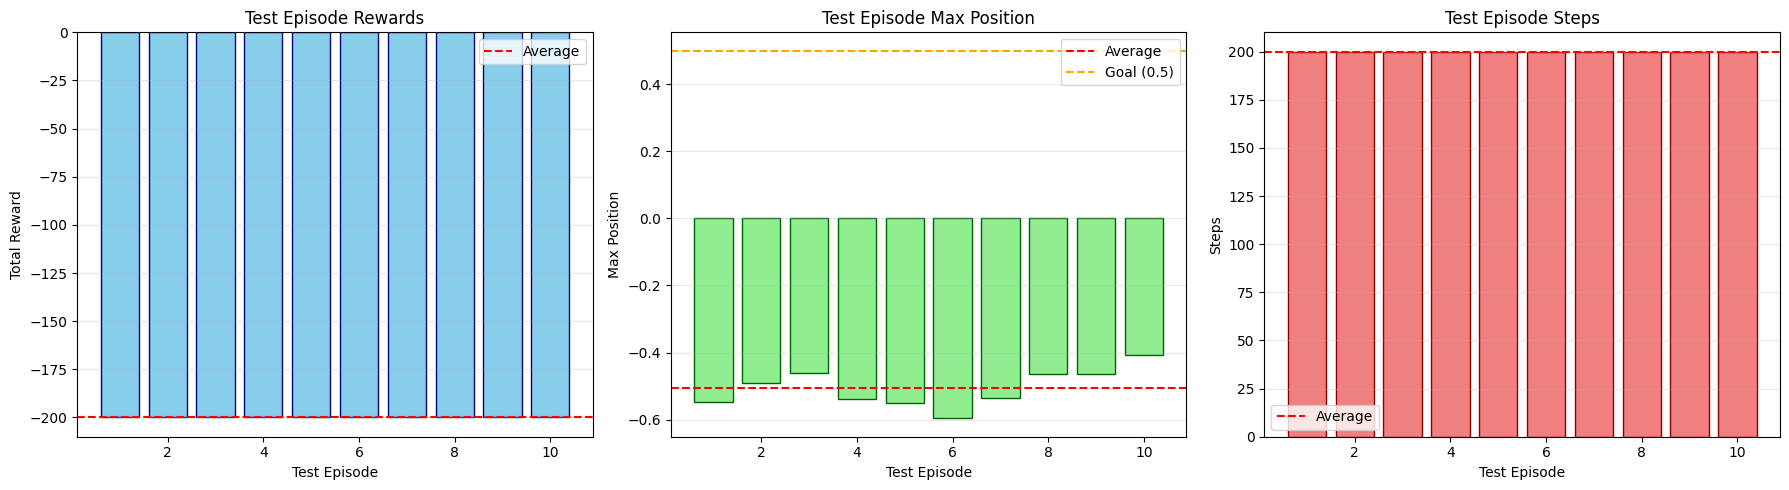

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, 11), test_rewards, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Test Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Test Episode Rewards')
axes[0].axhline(y=sum(test_rewards)/len(test_rewards), color='red', linestyle='--', label='Average')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1, 11), test_max_positions, color='lightgreen', edgecolor='darkgreen')
axes[1].set_xlabel('Test Episode')
axes[1].set_ylabel('Max Position')
axes[1].set_title('Test Episode Max Position')
axes[1].axhline(y=sum(test_max_positions)/len(test_max_positions), color='red', linestyle='--', label='Average')
axes[1].axhline(y=0.5, color='orange', linestyle='--', label='Goal (0.5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(range(1, 11), test_steps, color='lightcoral', edgecolor='darkred')
axes[2].set_xlabel('Test Episode')
axes[2].set_ylabel('Steps')
axes[2].set_title('Test Episode Steps')
axes[2].axhline(y=sum(test_steps)/len(test_steps), color='red', linestyle='--', label='Average')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [ ]:
# Создаем окружение с рендерингом
env_render = gym.make('MountainCar-v0', render_mode='human')

state, info = env_render.reset()
state = th.tensor(state, dtype=th.float32, device=device).unsqueeze(0)

done = False
steps = 0
policy.cfg.epsilon = 0.0  # Только жадная стратегия

print("Демонстрация обученной модели...")
while not done and steps < 1000:
    action = policy.get_best_action(state)
    observation, reward, terminated, truncated, info = env_render.step(action)
    done = terminated or truncated
    steps += 1

    state = th.tensor(observation, dtype=th.float32, device=device).unsqueeze(0)

print(f"Finished in {steps} steps, Max position: {observation[0]:.4f}")
env_render.close()


Демонстрация обученной модели...
Finished in 200 steps, Max position: -0.7999


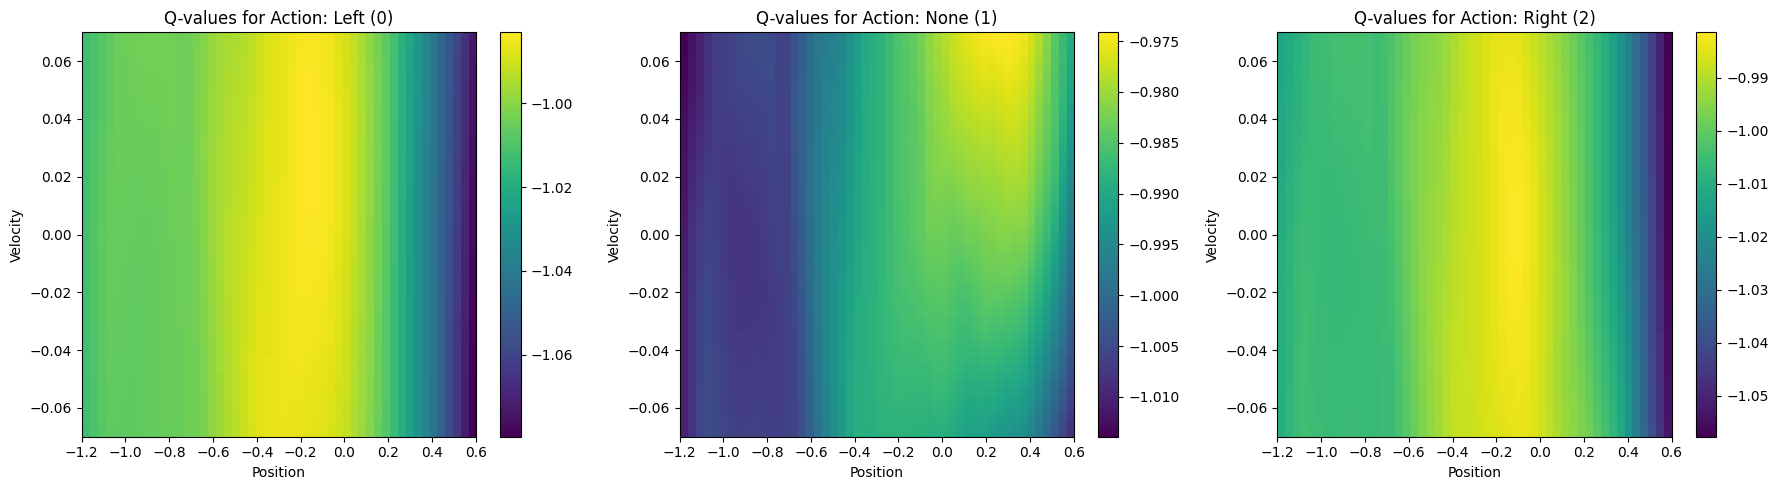

In [ ]:
# Визуализация Q-значений в пространстве состояний
import numpy as np

positions = np.linspace(-1.2, 0.6, 50)
velocities = np.linspace(-0.07, 0.07, 50)

q_values_map = np.zeros((50, 50, 3))

policy.cfg.epsilon = 0.0

for i, pos in enumerate(positions):
    for j, vel in enumerate(velocities):
        state = th.tensor([[pos, vel]], dtype=th.float32, device=device)
        with th.no_grad():
            q_values = policy.policy_network(state).cpu().numpy()[0]
        q_values_map[j, i] = q_values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
actions = ['Left (0)', 'None (1)', 'Right (2)']

for idx in range(3):
    im = axes[idx].imshow(q_values_map[:, :, idx], extent=[-1.2, 0.6, -0.07, 0.07],
                          aspect='auto', origin='lower', cmap='viridis')
    axes[idx].set_xlabel('Position')
    axes[idx].set_ylabel('Velocity')
    axes[idx].set_title(f'Q-values for Action: {actions[idx]}')
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()
